# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?

Adding a penalty discourages the model from using large coefficients. Without it, the model may overfit by making parameters very large to perfectly match training data. The penalty forces the model to stay "simple," so it focuses on the most important patterns rather than noise.

2. How does regularization provide a way of exploring the bias-variance trade-off?

Regularization introduces bias (by shrinking coefficients), but reduces variance (by preventing overfitting). By tuning the strength of the penalty, we can explore different points along the trade-off:
- Small penalty -> low bias, high variance
- Large penalty -> high bias, low variance

3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?

- LASSO (L1) can shrink some coefficients exactly to zero -> performs feature selection
- Ridge (L2) shrinks coefficients toward zero but never makes them exactly zero -> keeps all features

  For the two problems:
- LASSO -> better when only a few predictors are truly important
- Ridge -> better when many small/related predictors

4. How do we typically scale variables for use in regularized regression? Why?

We typically standardize variables (mean = 0, std = 1) because the penalty depends on coefficient size. Without scaling, variables with larger units would be penalized more, which is unfair and distorts the model.

5. How is the penalty $\alpha$ typically selected?

α is usually chosen using cross-validation. We try different values and pick the one that minimizes prediction error on validation data.

6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

No, you do not include the penalty term in evaluating the cross validated MSE when conducting cross validation. We evaluate performance using prediction error (MSE) only, not the penalty term because we care about how well the model predicts new data, not how small the coefficients are.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [3]:
import os
print(os.listdir("/content/sample_data"))

['README.md', 'anscombe.json', 'cars_hw.csv', 'mnist_test.csv', 'california_housing_train.csv', 'california_housing_test.csv', 'mnist_train_small.csv']


In [4]:
print(df.columns)

Index(['Unnamed: 0', 'Make', 'Make_Year', 'Color', 'Body_Type', 'Mileage_Run',
       'No_of_Owners', 'Seating_Capacity', 'Fuel_Type', 'Transmission',
       'Transmission_Type', 'Price'],
      dtype='object')


In [10]:
#2.1 (a and b)

import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# Load data
df = pd.read_csv("/content/sample_data/cars_hw.csv")

# Drop useless column
df = df.drop(columns=["Unnamed: 0"])

# Create Age
df["Age"] = 2026 - df["Make_Year"]

# Features and target
X = df[["Mileage_Run", "Age"]]
y = df["Price"]

# Polynomial features (degree 3)
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

In [14]:
#2,2

from sklearn.linear_model import LinearRegression

# Fit model
model = LinearRegression()
model.fit(X_scaled, y)

# Get feature names + coefficients
feature_names = poly.get_feature_names_out(["Mileage_Run", "Age"])

for name, coef in zip(feature_names, model.coef_):
    print(name, coef)

Mileage_Run 911774.8402226233
Age -248172.18553827342
Mileage_Run^2 -207292.6283285836
Mileage_Run Age -1671212.3563918793
Age^2 350550.7198774649
Mileage_Run^3 -65144.89659917212
Mileage_Run^2 Age 338819.4599153141
Mileage_Run Age^2 716781.5818001862
Age^3 -210037.88763612031


2.2 The interaction between Mileage_Run and Age is negative. This indicates that as a car gets older, the negative impact of mileage on price becomes stronger, meaning higher mileage reduces price even more for older vehicles.

In [17]:
#2.3

from sklearn.linear_model import LassoCV

# Define alphas (as given in hint)
alphas = np.logspace(1, 3, 20)

# LASSO with 20-fold CV
lasso = LassoCV(alphas=alphas, cv=20)
lasso.fit(X_scaled, y)

# Best alpha
best_alpha = lasso.alpha_
print("Best alpha:", best_alpha)

Best alpha: 69.51927961775606


2.3 I used LassoCV with 20-fold cross-validation over a grid of α values from 10 to 1000. The model selected an optimal α of 69.52, which minimizes the cross-validated mean squared error

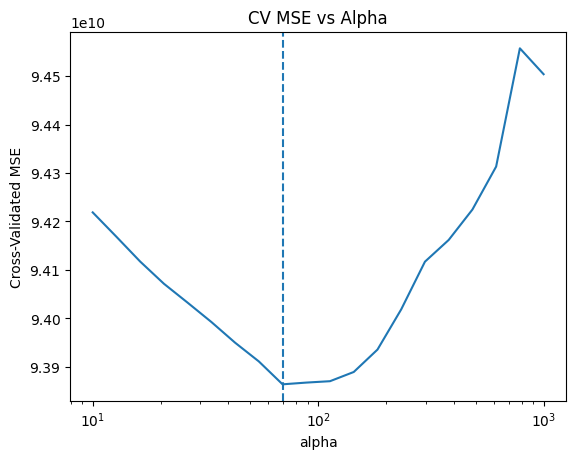

In [18]:
#2.4

import matplotlib.pyplot as plt

# Mean CV MSE across folds
mse_mean = np.mean(lasso.mse_path_, axis=1)

# Plot
plt.figure()
plt.plot(lasso.alphas_, mse_mean)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross-Validated MSE")
plt.title("CV MSE vs Alpha")

# Mark best alpha
plt.axvline(lasso.alpha_, linestyle="--")
plt.show()

2.4 The cross-validated MSE decreases as α increases from small values, reaches a minimum around α ≈ 69.5, and then increases again for larger α. This demonstrates the bias-variance trade-off, where small α leads to overfitting and large α leads to underfitting

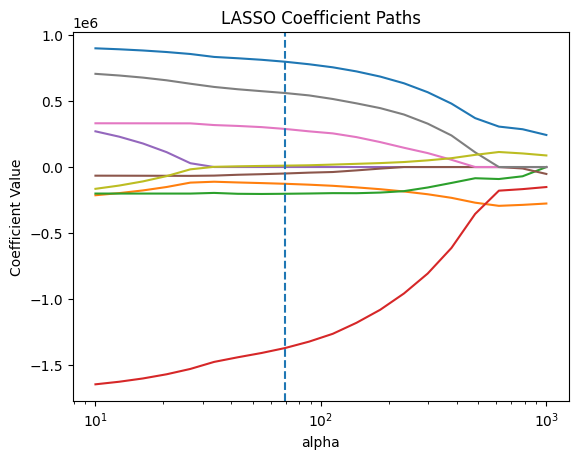

In [19]:
#2.5

from sklearn.linear_model import Lasso

coefs = []

# Compute coefficients for each alpha
for a in alphas:
    l = Lasso(alpha=a, max_iter=10000)
    l.fit(X_scaled, y)
    coefs.append(l.coef_)

coefs = np.array(coefs)

# Plot
plt.figure()

for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient Value")
plt.title("LASSO Coefficient Paths")

# Mark best alpha
plt.axvline(lasso.alpha_, linestyle="--")

plt.show()

2.5 As α increases, the coefficients shrink toward zero. Some coefficients become exactly zero, indicating that LASSO performs feature selection by removing less important variables. Larger α values result in simpler models with fewer active features.

In [20]:
#2.6

lasso_coefs = lasso.coef_
feature_names = poly.get_feature_names_out(["Mileage_Run", "Age"])

# Count
num_zero = np.sum(lasso_coefs == 0)
total = len(lasso_coefs)

print("Total features:", total)
print("Zero coefficients:", num_zero)
print("Proportion zero:", num_zero / total)

# Show selected (non-zero) features
print("\nSelected features:")
for name, coef in zip(feature_names, lasso_coefs):
    if coef != 0:
        print(name, coef)

Total features: 9
Zero coefficients: 0
Proportion zero: 0.0

Selected features:
Mileage_Run 611783.8687672444
Age -397507.78704233415
Mileage_Run^2 -519555.26186708576
Mileage_Run Age -473871.4004586164
Age^2 230721.07872438311
Mileage_Run^3 97835.64135339324
Mileage_Run^2 Age 318218.774587956
Mileage_Run Age^2 -35056.210189920275
Age^3 42493.187415540124


2.6

Out of 9 total features, LASSO sets 0 coefficients to zero, resulting in a proportion of 0.0. This means that all features are retained in the model. While LASSO shrinks the coefficients, it does not eliminate any features in this case, suggesting that all polynomial terms contribute to predicting price.

In [21]:
#2.7

# Compare coefficients
for name, lin_coef, lasso_coef in zip(feature_names, model.coef_, lasso.coef_):
    print(name, "Linear:", lin_coef, "| LASSO:", lasso_coef)

Mileage_Run Linear: 911774.8402226233 | LASSO: 611783.8687672444
Age Linear: -248172.18553827342 | LASSO: -397507.78704233415
Mileage_Run^2 Linear: -207292.6283285836 | LASSO: -519555.26186708576
Mileage_Run Age Linear: -1671212.3563918793 | LASSO: -473871.4004586164
Age^2 Linear: 350550.7198774649 | LASSO: 230721.07872438311
Mileage_Run^3 Linear: -65144.89659917212 | LASSO: 97835.64135339324
Mileage_Run^2 Age Linear: 338819.4599153141 | LASSO: 318218.774587956
Mileage_Run Age^2 Linear: 716781.5818001862 | LASSO: -35056.210189920275
Age^3 Linear: -210037.88763612031 | LASSO: 42493.187415540124


2.7

Compared to linear regression, most LASSO coefficients decrease in magnitude due to regularization, indicating shrinkage. However, no coefficients are set to zero, so no features are eliminated. Additionally, some coefficients change sign between the linear and LASSO models, particularly among higher-order polynomial terms. This suggests that regularization not only reduces coefficient size but can also alter the direction of certain relationships to improve generalization.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?